# 📊 데이터 시각화

데이터 시각화는 복잡한 숫자 더미에서 의미를 찾아내고, 이를 전략적 의사결정의 근거로 변환하는 핵심 과정입니다. 우리가 작성하는 코드는 단순한 그림을 그리기 위함이 아니라, **데이터 뒤에 숨겨진 비즈니스 스토리를 발굴하고 제언하기 위한 도구**입니다.

이 교재는 실무에서 가장 강력한 무기가 될 두 가지 핵심 라이브러리의 필수 기능만을 다룹니다.
* **Matplotlib**: 데이터 시각화의 기초 뼈대를 잡는 도구
* **Seaborn**: 통계적 패턴을 아름답고 직관적으로 표현하는 도구

**[학습 준비] 필수 라이브러리 및 실무용 가상 데이터 세팅**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 및 마이너스 기호 깨짐 방지
import platform
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 실무 데이터 시뮬레이션 (100명의 고객 데이터)
np.random.seed(42)
data = {
    '날짜': pd.date_range(start='2023-01-01', periods=100),
    '마케팅비용': np.random.randint(10, 100, 100),
    '매출액': np.random.randint(100, 500, 100) + np.arange(100)*2,
    '고객연령': np.random.normal(35, 8, 100).astype(int),
    '유입채널': np.random.choice(['SNS', '검색', '이메일', '직접방문'], 100)
}
df = pd.DataFrame(data)
print("✅ 라이브러리 및 데이터 준비 완료!")
df

✅ 라이브러리 및 데이터 준비 완료!


,날짜,마케팅비용,매출액,고객연령,유입채널
0,2023-01-01,61,444,27,검색
1,2023-01-02,24,428,28,SNS
2,2023-01-03,81,112,31,이메일
3,2023-01-04,70,449,30,이메일
4,2023-01-05,30,236,18,직접방문
...,...,...,...,...,...
95,2023-04-06,50,426,33,직접방문
96,2023-04-07,38,609,37,SNS
97,2023-04-08,24,458,39,SNS
98,2023-04-09,54,520,33,직접방문


---
## PART 1. Matplotlib 기능: 시각화의 뼈대 세우기
Matplotlib은 도화지(Figure) 위에 우리가 원하는 형태의 그래프(Plot)를 자유롭게 그릴 수 있게 해줍니다.

### 1. 플롯(Plot) & 선 그래프(Line Plot)
* **비즈니스 목적**: 시간에 따른 데이터의 연속적인 변화와 트렌드 파악 (예: 일별 매출 추이)

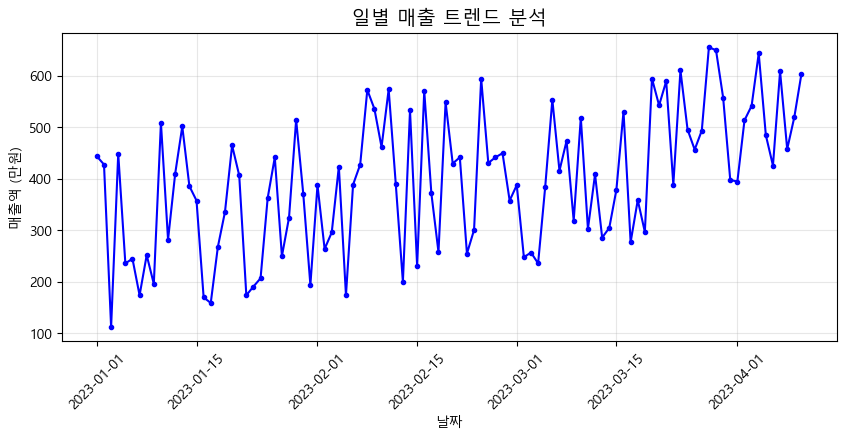

In [3]:
plt.figure(figsize=(10, 4))
# 기본적인 선 그래프 (plot)
plt.plot(df['날짜'], df['매출액'], color='blue', linestyle='-', marker='o', markersize=3)

plt.title('일별 매출 트렌드 분석', fontsize=14)
plt.xlabel('날짜')
plt.ylabel('매출액 (만원)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### 2. 막대 그래프 (Bar Chart)
* **비즈니스 목적**: 카테고리별 크기를 직관적으로 비교 (예: 채널별 총 매출액 비교)

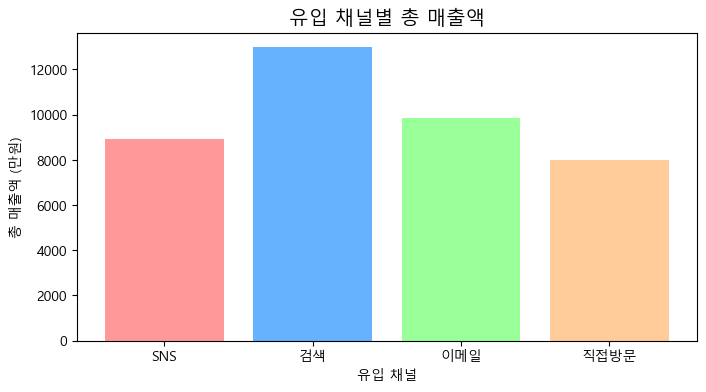

In [5]:
# 채널별 총 매출액 집계
channel_sales = df.groupby('유입채널')['매출액'].sum()

plt.figure(figsize=(8, 4))
plt.bar(channel_sales.index, channel_sales.values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])

plt.title('유입 채널별 총 매출액', fontsize=14)
plt.xlabel('유입 채널')
plt.ylabel('총 매출액 (만원)')
plt.show()

### 3. 파이 차트 (Pie Chart)
* **비즈니스 목적**: 전체 대비 각 항목의 점유율 및 비중 확인 (예: 마케팅 채널 점유율)

In [6]:
channel_sales

유입채널
SNS      8911
검색      12979
이메일      9854
직접방문     7968
Name: 매출액, dtype: int64

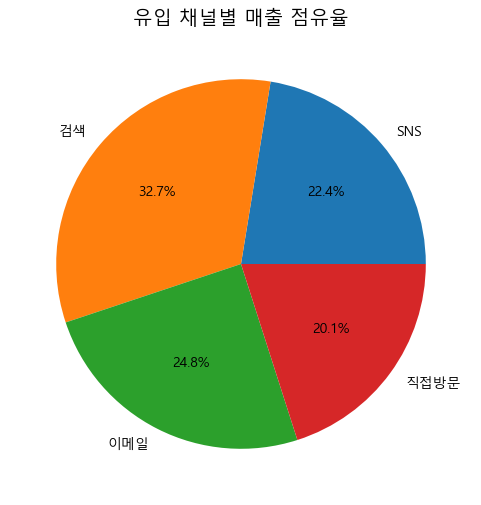

In [22]:
plt.figure(figsize=(6, 6))
# autopct: 퍼센트 표시 형식 설정
plt.pie(channel_sales.values, labels=channel_sales.index, autopct='%1.1f%%')

plt.title('유입 채널별 매출 점유율', fontsize=14)
plt.show()

### 4. 산점도 (Scatter Plot)
* **비즈니스 목적**: 두 변수 간의 상관관계 확인. 마케팅 예산 투입 대비 매출의 상관성 등 ROI 분석에 필수적입니다.

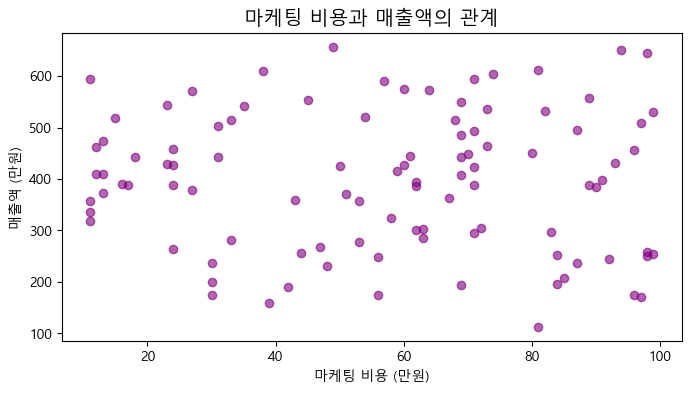

In [7]:
plt.figure(figsize=(8, 4))
plt.scatter(df['마케팅비용'], df['매출액'], alpha=0.6, color='purple')

plt.title('마케팅 비용과 매출액의 관계', fontsize=14)
plt.xlabel('마케팅 비용 (만원)')
plt.ylabel('매출액 (만원)')
plt.show()

### 5. 히스토그램 (Histogram)
* **비즈니스 목적**: 데이터의 분포 상태 파악. 타겟 고객층 설정이나 이상치 탐지에 활용됩니다.

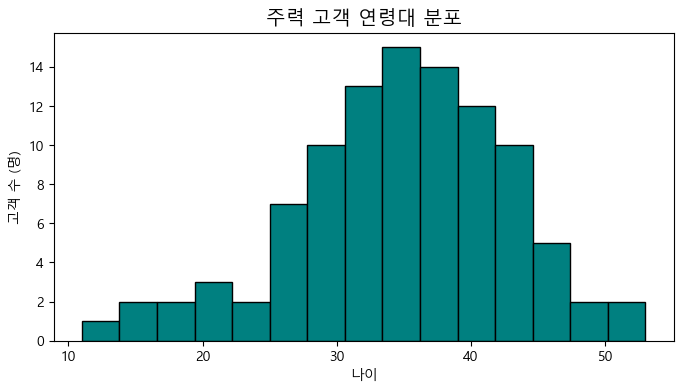

In [7]:
plt.figure(figsize=(8, 4))
# bins: 막대의 개수 (구간의 세밀함 결정)
plt.hist(df['고객연령'], bins=15, color='teal', edgecolor='black')

plt.title('주력 고객 연령대 분포', fontsize=14)
plt.xlabel('나이')
plt.ylabel('고객 수 (명)')
plt.show()

### 6. 서브플롯 (Subplot) & 7. 플롯 이미지 저장 (Savefig)
* **비즈니스 목적**: 여러 지표를 한눈에 볼 수 있는 대시보드(Dashboard)를 구성하고, 이를 보고서용 이미지로 추출합니다. 전략 기획서나 결과 보고서 작성 시 가장 유용한 기술입니다.

✅ 'business_dashboard_report.png' 파일이 저장되었습니다.


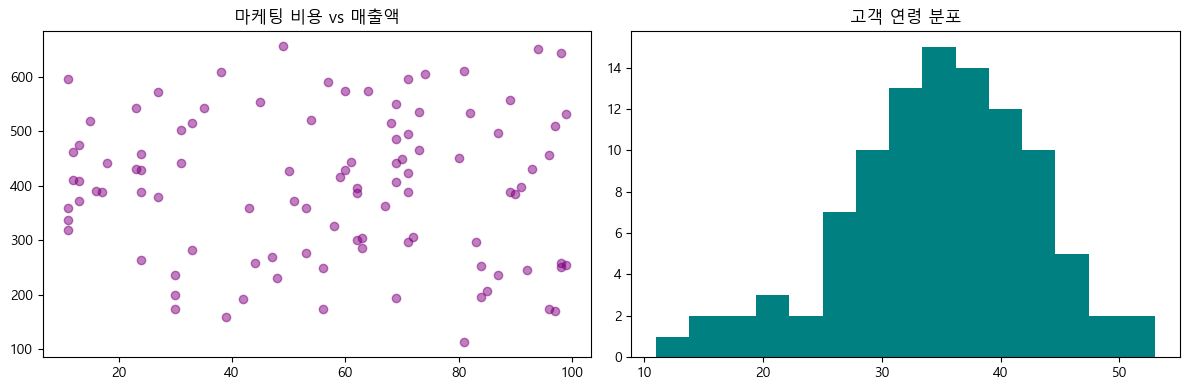

In [8]:
# 1행 2열의 도화지 생성
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 첫 번째 도화지: 산점도
axes[0].scatter(df['마케팅비용'], df['매출액'], color='purple', alpha=0.5)
axes[0].set_title('마케팅 비용 vs 매출액')

# 두 번째 도화지: 히스토그램
axes[1].hist(df['고객연령'], bins=15, color='teal')
axes[1].set_title('고객 연령 분포')

plt.tight_layout()

# 분석 결과를 이미지 파일로 저장하여 실무 보고서에 활용
plt.savefig('business_dashboard_report.png', dpi=300)
print("✅ 'business_dashboard_report.png' 파일이 저장되었습니다.")
plt.show()

---
## PART 2. Seaborn 기능: 통계적 패턴 탐색
Seaborn은 Matplotlib 기반으로 만들어져 코드가 훨씬 간결하며, 데이터 분석가의 강력한 판단 기준이 되는 통계적인 시각화를 기본적으로 지원합니다.

### 1. 히트맵 (Heatmap)
* **비즈니스 목적**: 여러 수치형 변수들 간의 상관관계를 한눈에 색상으로 요약합니다. 어떤 요인이 매출에 가장 큰 영향을 미치는지 직관적으로 판단할 수 있습니다.

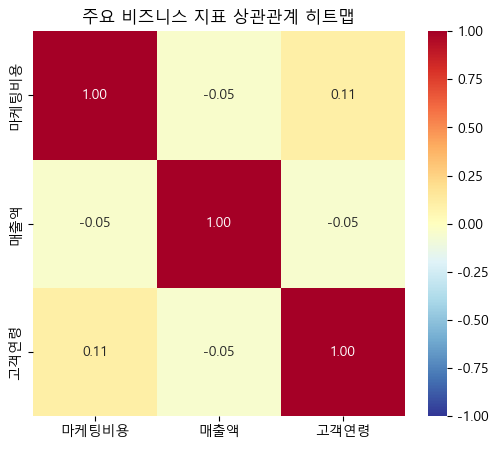

In [9]:
plt.figure(figsize=(6, 5))
# 수치형 데이터만 골라 상관계수 도출
corr_matrix = df[['마케팅비용', '매출액', '고객연령']].corr()

# annot=True: 칸 안에 수치 표기, cmap: 색상 테마
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', fmt=".2f", vmin=-1, vmax=1)
plt.title('주요 비즈니스 지표 상관관계 히트맵')
plt.show()

### 2. 클러스터맵 (Clustermap)
* **비즈니스 목적**: 특성이 비슷한 변수나 데이터를 자동으로 군집화(Clustering)하여 묶어줍니다. 고객 세분화(Segmentation) 전략을 짤 때 데이터의 숨겨진 구조를 파악하기 좋습니다.

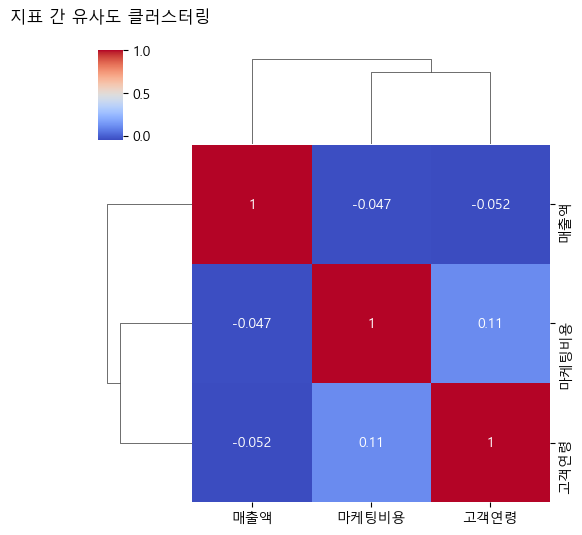

In [10]:
# 데이터 스케일 차이가 크면 클러스터링이 왜곡될 수 있으므로 상관계수 행렬을 사용
sns.clustermap(corr_matrix, annot=True, cmap='coolwarm', figsize=(5, 5))
plt.title('지표 간 유사도 클러스터링', pad=20)
plt.show()

### 3. 박스플롯 (Boxplot)
* **비즈니스 목적**: 집단 간 데이터의 분포(중앙값, 사분위수)와 비정상적인 값(Outlier, 이상치)을 동시에 확인합니다.

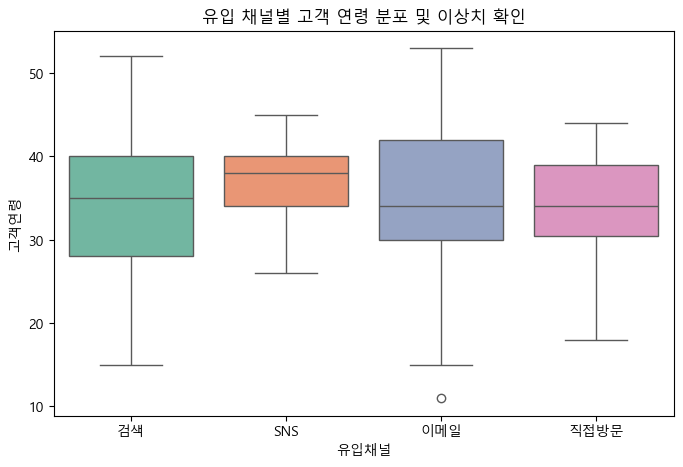

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='유입채널', y='고객연령', hue='유입채널', palette='Set2', legend=False)

plt.title('유입 채널별 고객 연령 분포 및 이상치 확인')
plt.show()

### 4. 카운트플롯 (Countplot)
* **비즈니스 목적**: 범주형 데이터(카테고리)의 빈도수를 세어줍니다. 코드가 매우 간결하여 데이터 탐색 초기 단계에서 자주 쓰입니다.

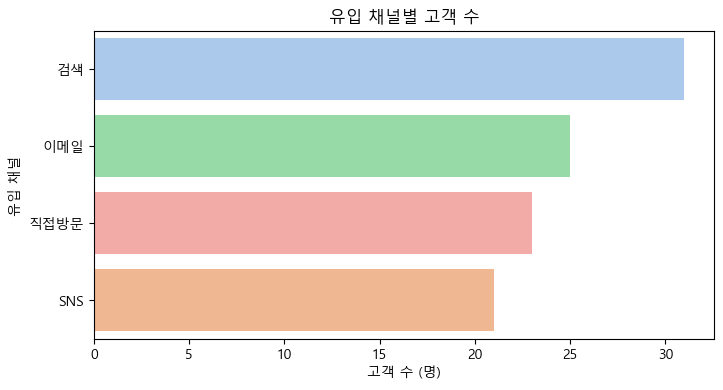

In [13]:
plt.figure(figsize=(8, 4))
# y축을 지정하면 가로 막대 그래프로 표현 가능
# y축 변수인 '유입채널'을 hue에 똑같이 할당하고 legend=False 추가
sns.countplot(
    data=df, 
    y='유입채널', 
    hue='유입채널', 
    palette='pastel', 
    order=df['유입채널'].value_counts().index, 
    legend=False
)
plt.title('유입 채널별 고객 수')
plt.xlabel('고객 수 (명)')
plt.ylabel('유입 채널')
plt.show()

### 5. 차원을 높이는 마법의 Key, 'hue' 파라미터 심화

Seaborn을 실무에서 가장 강력하게 만들어주는 기능이 바로 `hue` 파라미터입니다. `hue`는 사전적으로 '색조'를 의미하지만, 데이터 분석에서는 **'데이터를 나누는 3번째 차원(기준)'** 역할을 합니다.

데이터 기반 의사결정을 위해서는 단순히 전체 평균이나 2차원적인 요약을 넘어, **"어떤 타겟 고객층이, 어떤 마케팅 채널에서 다르게 반응하는가?"**와 같은 세부적인 패턴을 파악해야 합니다. 

아래 코드를 통해 `hue`를 적용하기 전과 후, 우리가 데이터에서 얻을 수 있는 정보의 양이 어떻게 달라지는지 비교해 봅시다.

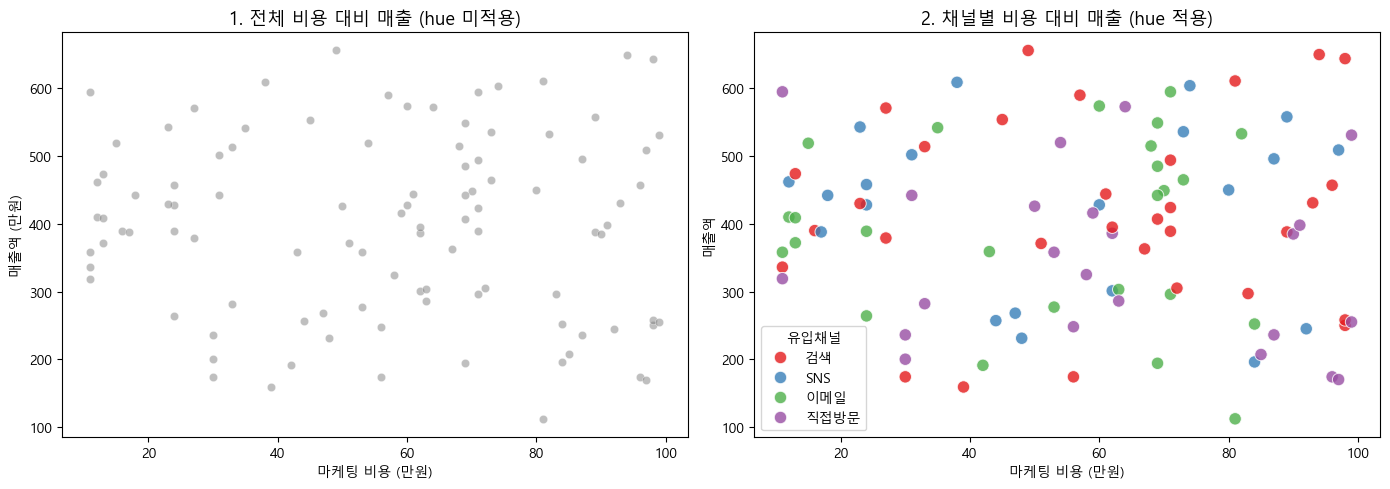

In [15]:
# 1. 산점도에서의 hue 비교: 2차원 분석 vs 3차원 분석
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [Graph 1] hue가 없는 경우: 전체적인 우상향 트렌드만 확인 가능
sns.scatterplot(data=df, x='마케팅비용', y='매출액', color='gray', alpha=0.5, ax=axes[0])
axes[0].set_title('1. 전체 비용 대비 매출 (hue 미적용)', fontsize=13)
axes[0].set_xlabel('마케팅 비용 (만원)')
axes[0].set_ylabel('매출액 (만원)')

# [Graph 2] hue='유입채널' 적용: 채널별 효율성(ROI) 비교 가능
sns.scatterplot(data=df, x='마케팅비용', y='매출액', hue='유입채널', palette='Set1', s=80, alpha=0.8, ax=axes[1])
axes[1].set_title('2. 채널별 비용 대비 매출 (hue 적용)', fontsize=13)
axes[1].set_xlabel('마케팅 비용 (만원)')

plt.tight_layout()
plt.show()

**💡 비즈니스 인사이트 도출 예시**
* **Graph 1**을 보면 "마케팅 비용을 많이 쓸수록 매출이 오르는구나"라는 1차원적인 사실만 알 수 있습니다.
* 하지만 **Graph 2**에 `hue`로 **'유입채널'** 차원을 추가하면, 점들의 색상이 구분되면서 "특정 채널(예: SNS)은 적은 비용으로도 높은 매출을 내고 있구나" 혹은 "직접 방문은 비용과 무관하게 매출이 일정하구나"와 같은 전략적인 해석이 가능해집니다.

---
이번에는 앞서 다룬 `countplot`에 `hue`를 제대로 적용하여, 카테고리 내의 세부 구성을 파악해 보겠습니다.

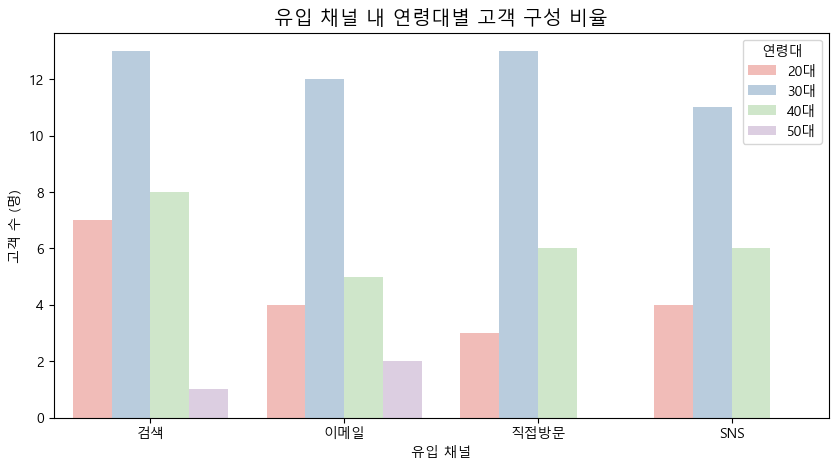

In [14]:
# 분석의 편의를 위해 '고객연령'을 '연령대(20대, 30대 등)' 파생 변수로 변환
df['연령대'] = (df['고객연령'] // 10 * 10).astype(str) + '대'

plt.figure(figsize=(10, 5))

# 유입 채널별 고객 수를 1차로 그리고, 그 안에서 연령대별로 색상을 나누어(hue) 2차 비교
sns.countplot(
    data=df, 
    x='유입채널', 
    hue='연령대', 
    palette='Pastel1',
    # 채널에 따라 정렬
    order=df['유입채널'].value_counts().index, 
    # 연령대 순서대로 범례 정렬
    hue_order=['20대', '30대', '40대', '50대'] 
)

plt.title('유입 채널 내 연령대별 고객 구성 비율', fontsize=14)
plt.xlabel('유입 채널')
plt.ylabel('고객 수 (명)')
# 범례 위치 조절
plt.legend(title='연령대', loc='upper right') 
plt.show()

이렇게 `hue`를 잘 활용하면, 데이터를 별도로 필터링하거나 여러 번 그래프를 그릴 필요 없이 코드 한 줄로 그룹 간의 차이를 완벽하게 시각화할 수 있습니다. 

단순한 코딩 기술(Technical Execution)을 넘어, 데이터를 입체적으로 분해하고 전략적인 스토리텔링을 이끌어내는 힘이 바로 여기서 나옵니다.